# Scientific Data Processing

## Scientific Python for Engineers Workshop - Hour 2

**Author:** Dilip Kalagotla  
**Contact:** dilip.kalagotla@gmail.com

## Learning Objectives

- Load data from CSV files using Pandas
- Explore and clean datasets
- Perform numerical operations with NumPy
- Create publication-quality visualizations

---

## Setup

First, let's import the libraries we'll need.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: make plots look nicer
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


---
## 1. Loading Data with Pandas

Pandas makes it easy to load data from various file formats:
- CSV: `pd.read_csv()`
- Excel: `pd.read_excel()`
- JSON: `pd.read_json()`
- And many more!

In [2]:
# Load the sample data
df = pd.read_csv('data/sample_data.csv')

# Display first few rows
print("First 5 rows:")
df.head()

First 5 rows:


,time,temperature,pressure,velocity_x,velocity_y,velocity_z,density
0,0.0,300.0,101325.0,10.5,0.0,0.0,1.225
1,0.1,301.2,101320.0,10.8,0.5,0.1,1.223
2,0.2,302.5,101315.0,11.2,1.0,0.2,1.221
3,0.3,303.8,101310.0,11.5,1.5,0.3,1.219
4,0.4,305.1,101305.0,11.9,2.0,0.4,1.217


In [3]:
# Display last few rows
print("Last 5 rows:")
df.tail()

Last 5 rows:


,time,temperature,pressure,velocity_x,velocity_y,velocity_z,density
16,1.6,311.2,101245.0,14.0,4.2,1.3,1.202
17,1.7,311.4,101240.0,14.1,4.3,1.3,1.201
18,1.8,311.6,101235.0,14.2,4.4,1.4,1.200
19,1.9,311.8,101230.0,14.3,4.5,1.4,1.199
20,2.0,312.0,101225.0,14.4,4.6,1.5,1.198


---
## 2. Exploring the Data

In [4]:
# Basic info about the DataFrame
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumn names: {df.columns.tolist()}")

Shape: 21 rows x 7 columns

Column names: ['time', 'temperature', 'pressure', 'velocity_x', 'velocity_y', 'velocity_z', 'density']


In [5]:
# Data types
print("Data types:")
print(df.dtypes)

Data types:
time           float64
temperature    float64
pressure       float64
velocity_x     float64
velocity_y     float64
velocity_z     float64
density        float64
dtype: object


In [6]:
# Summary statistics
print("Summary statistics:")
df.describe()

Summary statistics:


,time,temperature,pressure,velocity_x,velocity_y,velocity_z,density
count,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000
mean,1.000000,308.171429,101275.000000,12.976190,3.095238,0.857143,1.209333
std,0.620484,3.668807,31.024184,1.199127,1.363993,0.462138,0.008126
min,0.000000,300.000000,101225.000000,10.500000,0.000000,0.000000,1.198000
25%,0.500000,306.400000,101250.000000,12.200000,2.500000,0.500000,1.203000
50%,1.000000,309.500000,101275.000000,13.400000,3.600000,1.000000,1.208000
75%,1.500000,311.000000,101300.000000,13.900000,4.100000,1.200000,1.215000
max,2.000000,312.000000,101325.000000,14.400000,4.600000,1.500000,1.225000


In [7]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
time           0
temperature    0
pressure       0
velocity_x     0
velocity_y     0
velocity_z     0
density        0
dtype: int64


---
## 3. Accessing Data

There are multiple ways to access data in a DataFrame.

In [8]:
# Access a single column (returns a Series)
temperatures = df['temperature']
print(f"Temperature column type: {type(temperatures)}")
print(temperatures.head())

Temperature column type: <class 'pandas.Series'>
0    300.0
1    301.2
2    302.5
3    303.8
4    305.1
Name: temperature, dtype: float64


In [9]:
# Access multiple columns (returns a DataFrame)
velocity_data = df[['velocity_x', 'velocity_y', 'velocity_z']]
velocity_data.head()

,velocity_x,velocity_y,velocity_z
0,10.5,0.0,0.0
1,10.8,0.5,0.1
2,11.2,1.0,0.2
3,11.5,1.5,0.3
4,11.9,2.0,0.4


In [10]:
# Access by row index using .iloc (integer location)
print("Row 5:")
print(df.iloc[5])

Row 5:
time                0.500
temperature       306.400
pressure       101300.000
velocity_x         12.200
velocity_y          2.500
velocity_z          0.500
density             1.215
Name: 5, dtype: float64


In [11]:
# Access by row and column
print(f"Temperature at row 5: {df.iloc[5]['temperature']}")
print(f"Or using loc: {df.loc[5, 'temperature']}")

Temperature at row 5: 306.4
Or using loc: 306.4


In [12]:
# Boolean indexing (filtering)
high_temp = df[df['temperature'] > 310]
print(f"Rows where temperature > 310K:")
high_temp

Rows where temperature > 310K:


,time,temperature,pressure,velocity_x,velocity_y,velocity_z,density
12,1.2,310.2,101265.0,13.6,3.8,1.1,1.206
13,1.3,310.5,101260.0,13.7,3.9,1.1,1.205
14,1.4,310.7,101255.0,13.8,4.0,1.2,1.204
15,1.5,311.0,101250.0,13.9,4.1,1.2,1.203
16,1.6,311.2,101245.0,14.0,4.2,1.3,1.202
17,1.7,311.4,101240.0,14.1,4.3,1.3,1.201
18,1.8,311.6,101235.0,14.2,4.4,1.4,1.200
19,1.9,311.8,101230.0,14.3,4.5,1.4,1.199
20,2.0,312.0,101225.0,14.4,4.6,1.5,1.198


---
## 4. Data Manipulation

In [13]:
# Create a new column: velocity magnitude
df['velocity_magnitude'] = np.sqrt(
    df['velocity_x']**2 + 
    df['velocity_y']**2 + 
    df['velocity_z']**2
)

print("Added velocity_magnitude column:")
df[['velocity_x', 'velocity_y', 'velocity_z', 'velocity_magnitude']].head()

Added velocity_magnitude column:


,velocity_x,velocity_y,velocity_z,velocity_magnitude
0,10.5,0.0,0.0,10.500000
1,10.8,0.5,0.1,10.812030
2,11.2,1.0,0.2,11.246333
3,11.5,1.5,0.3,11.601293
4,11.9,2.0,0.4,12.073525


In [14]:
# Convert temperature from Kelvin to Celsius
df['temperature_celsius'] = df['temperature'] - 273.15

print("Temperature comparison:")
df[['temperature', 'temperature_celsius']].head()

Temperature comparison:


,temperature,temperature_celsius
0,300.0,26.85
1,301.2,28.05
2,302.5,29.35
3,303.8,30.65
4,305.1,31.95


In [15]:
# Calculate dynamic pressure (0.5 * rho * V^2)
df['dynamic_pressure'] = 0.5 * df['density'] * df['velocity_magnitude']**2

print("Dynamic pressure:")
df[['density', 'velocity_magnitude', 'dynamic_pressure']].head()

Dynamic pressure:


,density,velocity_magnitude,dynamic_pressure
0,1.225,10.500000,67.528125
1,1.223,10.812030,71.484350
2,1.221,11.246333,77.216040
3,1.219,11.601293,82.032605
4,1.217,12.073525,88.701045


---
## 5. NumPy Operations

Pandas and NumPy work seamlessly together.

In [16]:
# Convert DataFrame columns to NumPy arrays
time_array = df['time'].values
temp_array = df['temperature'].values

print(f"Type: {type(time_array)}")
print(f"Array shape: {time_array.shape}")

Type: <class 'numpy.ndarray'>
Array shape: (21,)


In [17]:
# NumPy statistical operations
print(f"Mean temperature: {np.mean(temp_array):.2f} K")
print(f"Std temperature: {np.std(temp_array):.2f} K")
print(f"Max temperature: {np.max(temp_array):.2f} K")
print(f"Min temperature: {np.min(temp_array):.2f} K")

Mean temperature: 308.17 K
Std temperature: 3.58 K
Max temperature: 312.00 K
Min temperature: 300.00 K


In [18]:
# Numerical differentiation (temperature rate of change)
dT_dt = np.gradient(temp_array, time_array)
df['dT_dt'] = dT_dt

print("Temperature rate of change (K/s):")
df[['time', 'temperature', 'dT_dt']].head(10)

Temperature rate of change (K/s):


,time,temperature,dT_dt
0,0.0,300.0,12.0
1,0.1,301.2,12.5
2,0.2,302.5,13.0
3,0.3,303.8,13.0
4,0.4,305.1,13.0
5,0.5,306.4,10.5
6,0.6,307.2,8.0
7,0.7,308.0,6.5
8,0.8,308.5,5.0
9,0.9,309.0,5.0


In [19]:
# Numerical integration (total impulse from velocity)
# Using trapezoidal rule
total_displacement_x = np.trapezoid(df['velocity_x'], df['time'])
print(f"Total X displacement: {total_displacement_x:.2f} m")

Total X displacement: 26.01 m


---
## 6. Visualization with Matplotlib

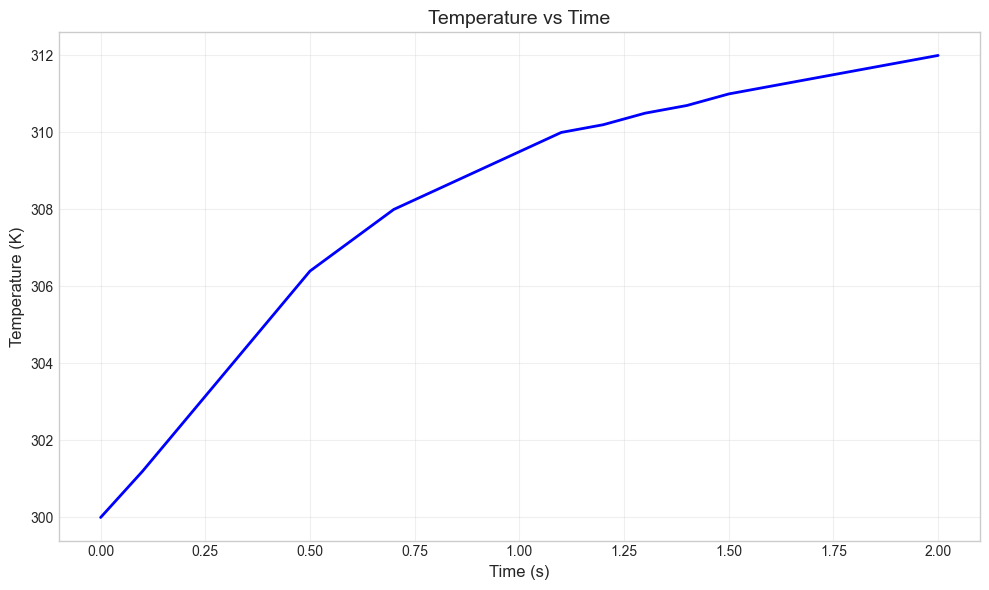

In [20]:
# Simple time series plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['time'], df['temperature'], 'b-', linewidth=2)
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Temperature (K)', fontsize=12)
ax.set_title('Temperature vs Time', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

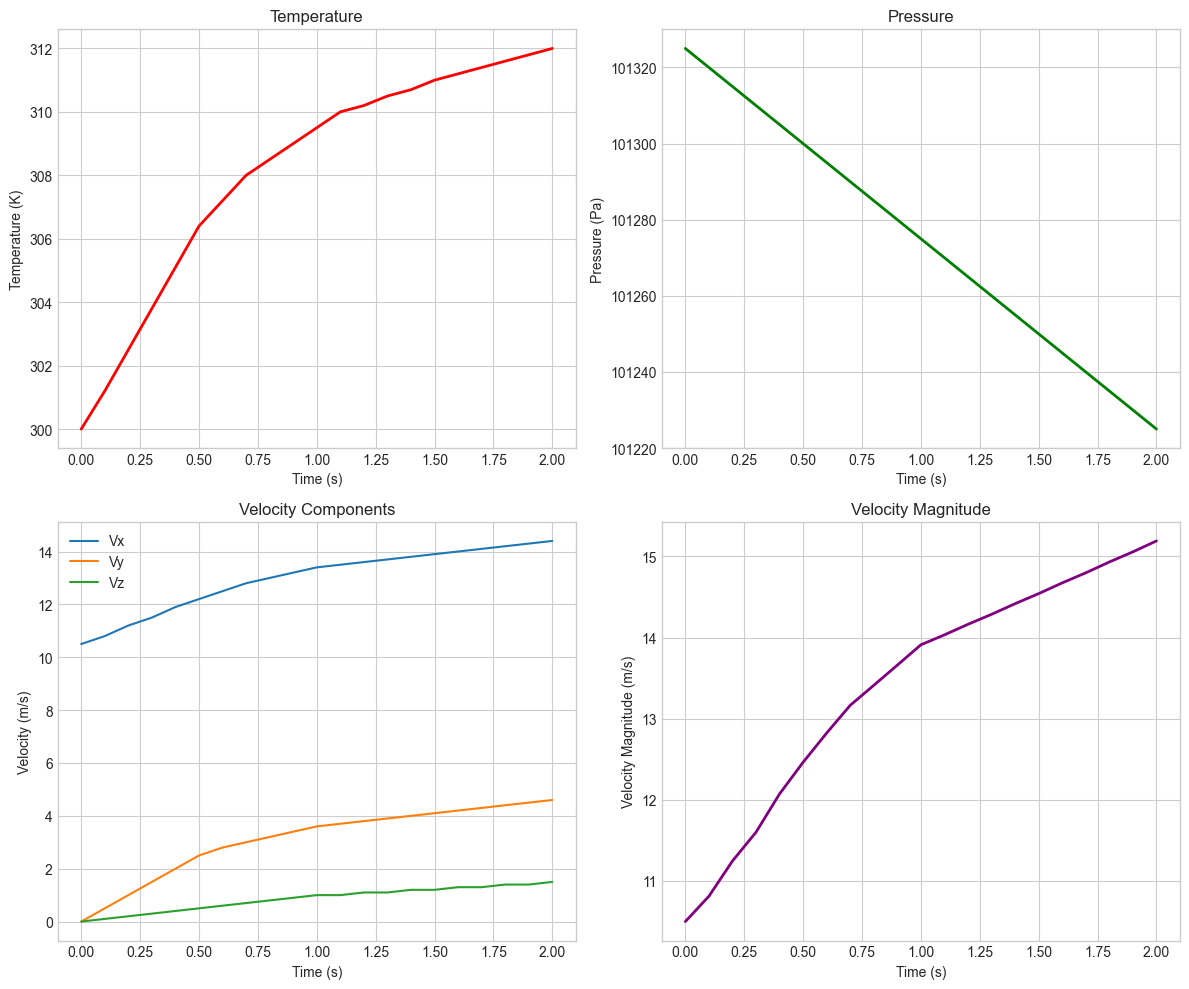

In [21]:
# Multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Temperature
axes[0, 0].plot(df['time'], df['temperature'], 'r-', linewidth=2)
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Temperature (K)')
axes[0, 0].set_title('Temperature')

# Pressure
axes[0, 1].plot(df['time'], df['pressure'], 'g-', linewidth=2)
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Pressure (Pa)')
axes[0, 1].set_title('Pressure')

# Velocity components
axes[1, 0].plot(df['time'], df['velocity_x'], label='Vx')
axes[1, 0].plot(df['time'], df['velocity_y'], label='Vy')
axes[1, 0].plot(df['time'], df['velocity_z'], label='Vz')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Velocity (m/s)')
axes[1, 0].set_title('Velocity Components')
axes[1, 0].legend()

# Velocity magnitude
axes[1, 1].plot(df['time'], df['velocity_magnitude'], 'purple', linewidth=2)
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Velocity Magnitude (m/s)')
axes[1, 1].set_title('Velocity Magnitude')

plt.tight_layout()
plt.show()

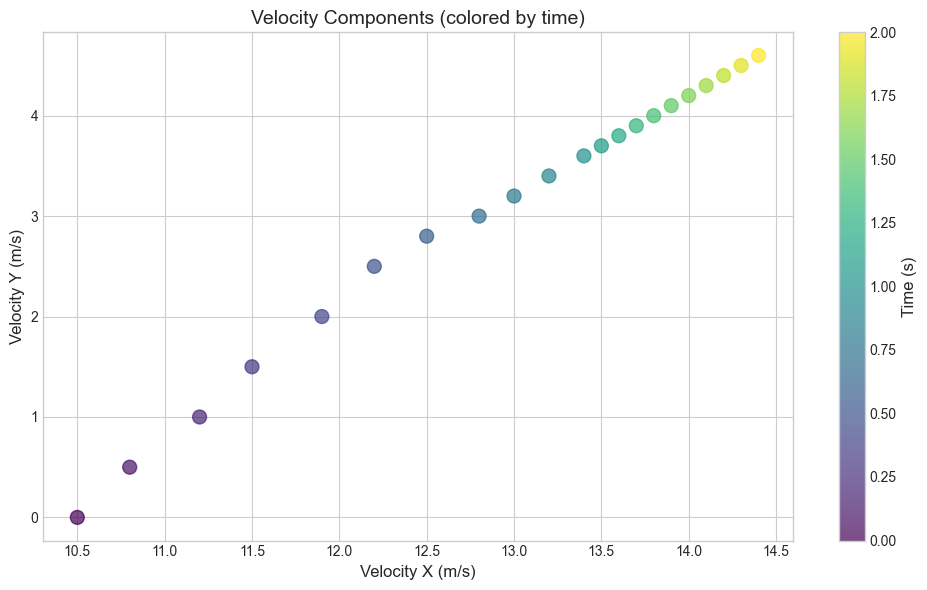

In [22]:
# Scatter plot with colorbar
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df['velocity_x'], 
    df['velocity_y'], 
    c=df['time'], 
    cmap='viridis',
    s=100,
    alpha=0.7
)

ax.set_xlabel('Velocity X (m/s)', fontsize=12)
ax.set_ylabel('Velocity Y (m/s)', fontsize=12)
ax.set_title('Velocity Components (colored by time)', fontsize=14)

cbar = plt.colorbar(scatter)
cbar.set_label('Time (s)', fontsize=12)

plt.tight_layout()
plt.show()

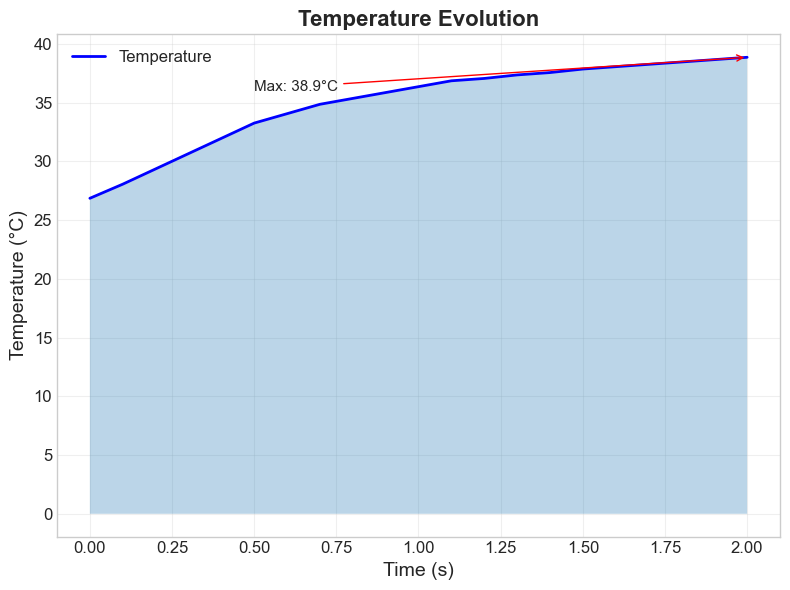

In [23]:
# Publication-quality figure
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(df['time'], df['temperature_celsius'], 'b-', linewidth=2, label='Temperature')
ax.fill_between(df['time'], df['temperature_celsius'], alpha=0.3)

ax.set_xlabel('Time (s)', fontsize=14)
ax.set_ylabel('Temperature (°C)', fontsize=14)
ax.set_title('Temperature Evolution', fontsize=16, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Add annotations
max_idx = df['temperature_celsius'].idxmax()
ax.annotate(
    f'Max: {df.loc[max_idx, "temperature_celsius"]:.1f}°C',
    xy=(df.loc[max_idx, 'time'], df.loc[max_idx, 'temperature_celsius']),
    xytext=(0.5, 36),
    fontsize=11,
    arrowprops=dict(arrowstyle='->', color='red')
)

plt.tight_layout()

# Save the figure
# fig.savefig('temperature_plot.png', dpi=300, bbox_inches='tight')

plt.show()

---
## 7. Saving Processed Data

In [24]:
# Save to CSV
# df.to_csv('data/processed_data.csv', index=False)
# print("Data saved to processed_data.csv")

In [25]:
# Save to Excel (requires openpyxl)
# df.to_excel('data/processed_data.xlsx', index=False)
# print("Data saved to processed_data.xlsx")

---
## 8. Template: Load Your Own Data

Replace the cells below with your own data loading and processing code.

In [26]:
# ============================================
# YOUR DATA LOADING CODE HERE
# ============================================

# Example:
# my_data = pd.read_csv('path/to/your/data.csv')
# my_data.head()

In [27]:
# ============================================
# YOUR DATA EXPLORATION CODE HERE
# ============================================

# Example:
# print(my_data.describe())
# print(my_data.isnull().sum())

In [28]:
# ============================================
# YOUR DATA PROCESSING CODE HERE
# ============================================

# Example:
# my_data['new_column'] = my_data['col1'] + my_data['col2']

In [29]:
# ============================================
# YOUR VISUALIZATION CODE HERE
# ============================================

# Example:
# plt.figure(figsize=(10, 6))
# plt.plot(my_data['x'], my_data['y'])
# plt.xlabel('X Label')
# plt.ylabel('Y Label')
# plt.title('My Plot')
# plt.show()

---
## Summary

You've learned how to:
- Load data from CSV files using Pandas
- Explore datasets (shape, dtypes, statistics, missing values)
- Access and filter data
- Create new columns and perform calculations
- Use NumPy for numerical operations
- Create various types of plots with Matplotlib

**Next:** Move to Hour 3 to learn about Deep Neural Networks with PyTorch!